# Time Series Analysis

## Objective

The purpose of this analysis is to understand how sales and orders change over time.

Key Questions:

- How do daily sales fluctuate?
- Which days generate the highest revenue?
- Are there visible trends over time?
- What business actions can be taken from these trends?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
daily_revenue = (
    df.groupby('Date')['Amount']
    .sum()
)

daily_revenue.head()

,Amount
Date,
2022-03-31,101683.85
2022-04-01,865478.60
2022-04-02,913101.53
2022-04-03,1011763.38
2022-04-04,882059.17


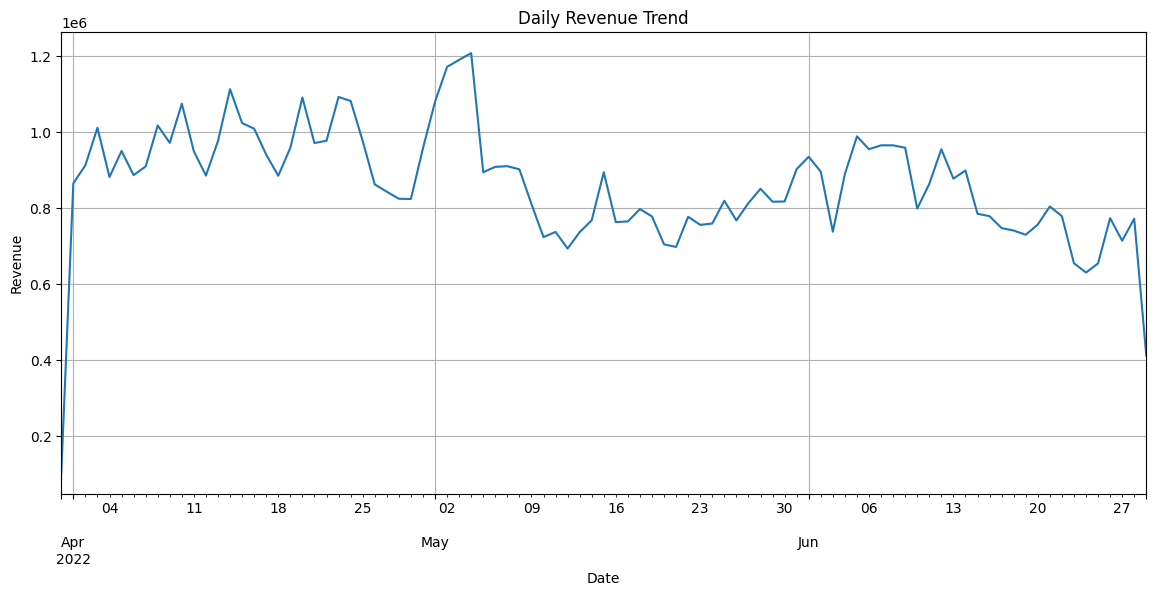

In [5]:
plt.figure(figsize=(14,6))

daily_revenue.plot()

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

## Daily Revenue Insights

- Revenue fluctuates throughout the period.
- Peak sales days indicate periods of high customer demand.


In [6]:
daily_orders = (
    df.groupby('Date')['Order ID']
    .nunique()
)

In [7]:
daily_orders.head()

,Order ID
Date,
2022-03-31,158
2022-04-01,1363
2022-04-02,1452
2022-04-03,1565
2022-04-04,1376


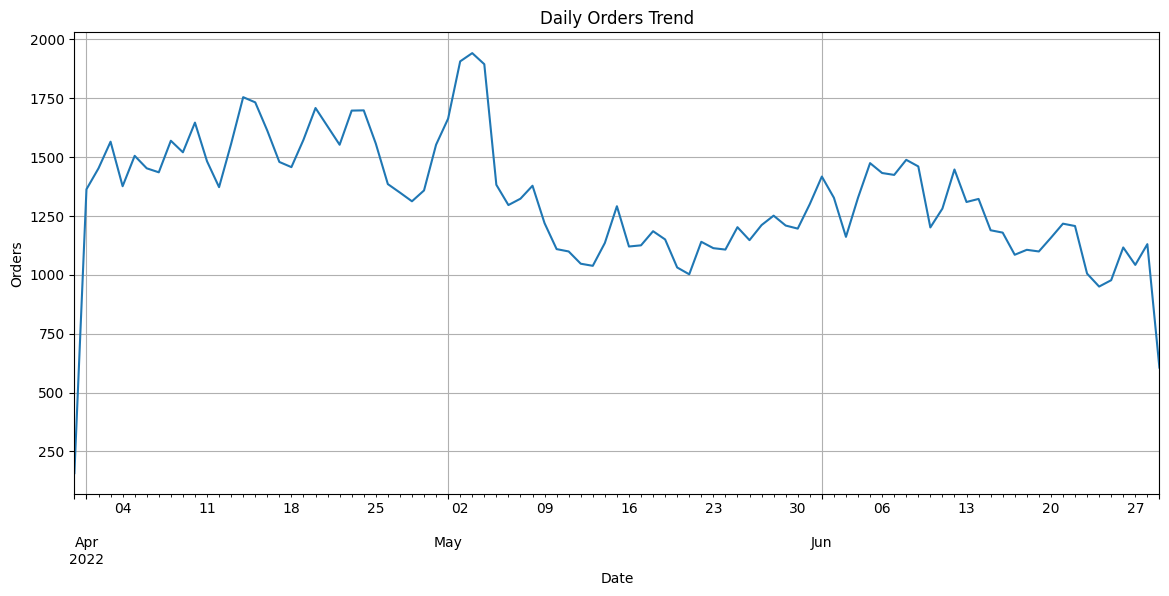

In [10]:
plt.figure(figsize=(14,6))

daily_orders.plot()

plt.title('Daily Orders Trend')
plt.xlabel('Date')
plt.ylabel('Orders')

plt.grid(True)

plt.show()

In [11]:
daily_revenue_ma = (
    daily_revenue
    .rolling(window=7)
    .mean()
)

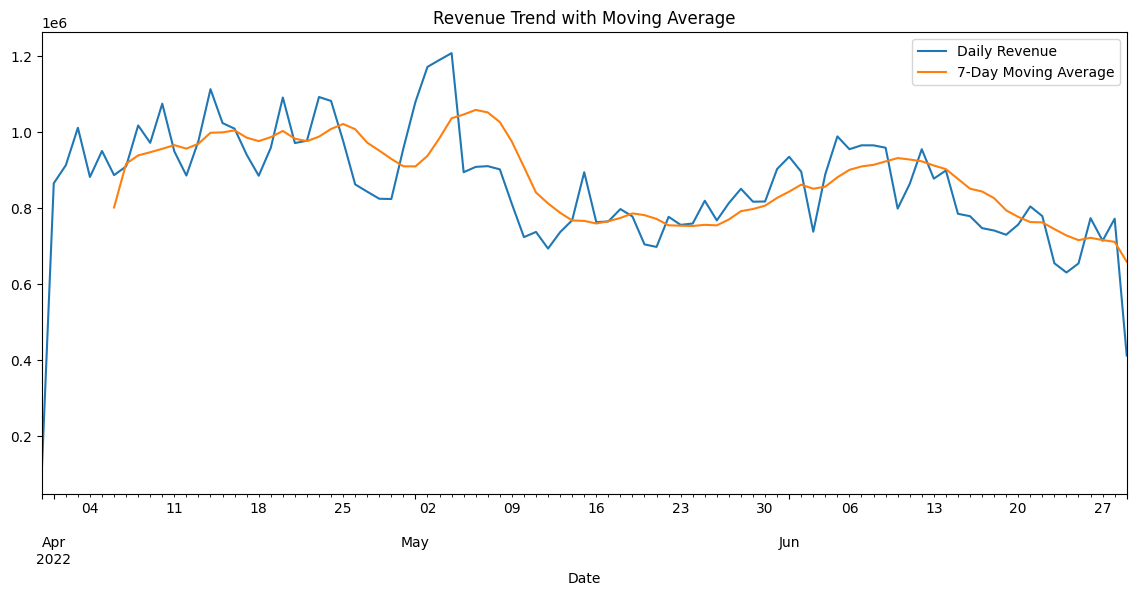

In [12]:
plt.figure(figsize=(14,6))

daily_revenue.plot(label='Daily Revenue')

daily_revenue_ma.plot(
    label='7-Day Moving Average'
)

plt.legend()

plt.title('Revenue Trend with Moving Average')

plt.show()

## Moving Average Insights

The moving average smooths daily fluctuations and reveals the underlying revenue trend.

In [16]:
df['Weekday'] = df['Date'].dt.day_name()

In [17]:
weekday_revenue = (
    df.groupby('Weekday')['Amount']
    .sum()
)

In [18]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_revenue = weekday_revenue.reindex(
    weekday_order
)

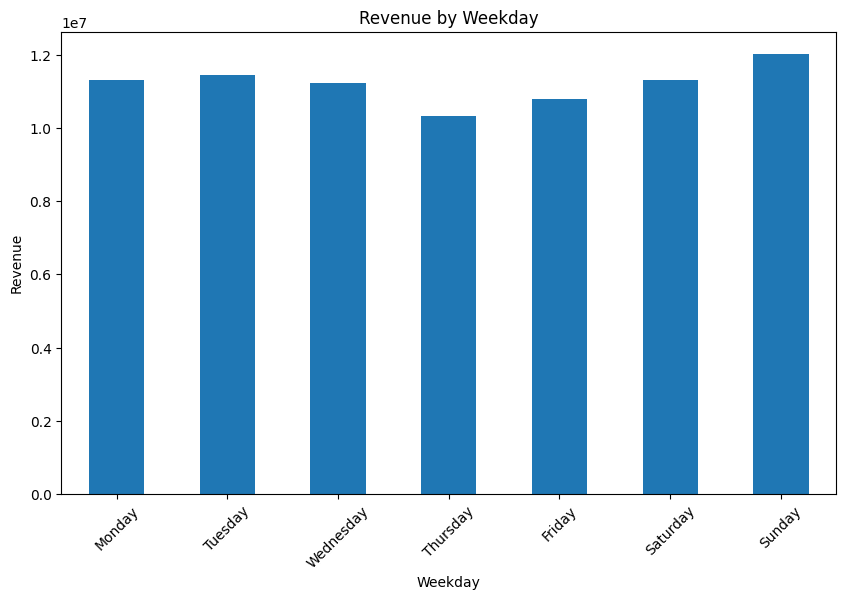

In [20]:
plt.figure(figsize=(10,6))

weekday_revenue.plot(kind='bar')

plt.title('Revenue by Weekday')
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.ylabel('Revenue')


plt.show()

In [22]:
weekday_orders = (
    df.groupby('Weekday')['Order ID']
    .nunique()
)

weekday_orders = weekday_orders.reindex(
    weekday_order
)

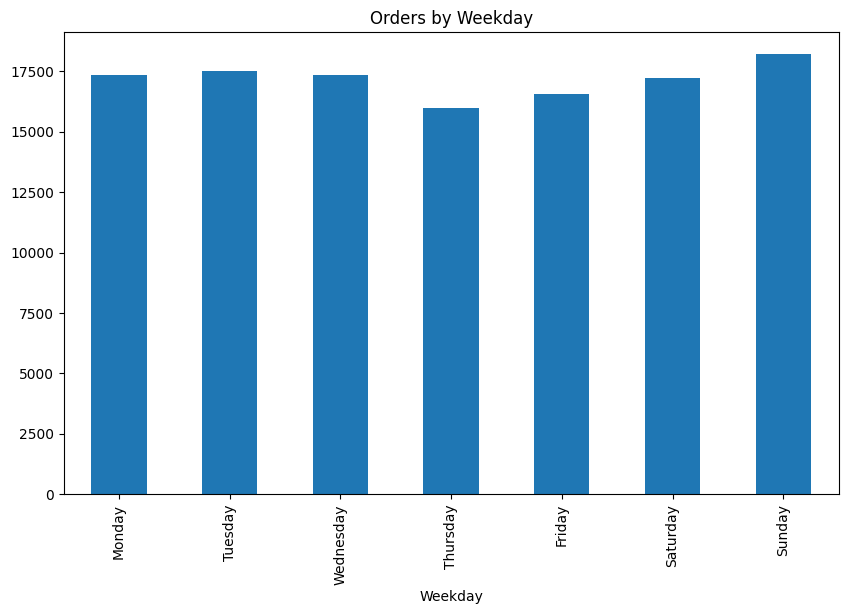

In [23]:
plt.figure(figsize=(10,6))

weekday_orders.plot(kind='bar')

plt.title('Orders by Weekday')

plt.show()

In [24]:
daily_revenue.sort_values(
    ascending=False
).head(10)

,Amount
Date,
2022-05-04,1208509.17
2022-05-03,1190672.59
2022-05-02,1172327.06
2022-04-14,1113487.56
2022-04-23,1092882.62
2022-04-20,1091550.41
2022-04-24,1082483.95
2022-05-01,1079957.52
2022-04-10,1075234.03


## Peak Revenue Days

These dates represent the strongest sales performance and may correspond to promotions, campaigns, or seasonal demand.

# Business Recommendations

1. Schedule promotions on high-performing weekdays.
2. Investigate causes of peak sales days.
3. Use moving averages for forecasting trends.
4. Optimize inventory before high-demand periods.
5. Monitor revenue declines early using trend analysis.

# Key Findings

## Time Series Analysis

1. Highest Revenue Day: 4 May 2022
2. Highest Revenue Weekday: Sunday
3. Highest Order Weekday: Sunday
4. Peak Revenue Period: Start of May(from 1 May to 5 May)
5. Trend Direction: Positive to Negative

## Conclusion

Revenue patterns show clear variations over time. Understanding daily and weekly trends can help improve marketing, inventory planning, and demand forecasting.